# Random Forest (Corregido) - Comparación con Árboles
Este notebook replica EXACTAMENTE el preprocessing usado en los árboles para hacer una comparación válida.

In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

## Cargar datos

In [12]:
df = pd.read_parquet("data/listings_clean.parquet")

## Preprocesamiento (IGUAL que árboles)

In [13]:
# Convertir price a numérico
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Eliminar nulos en price
df = df.dropna(subset=["price"])

# Seleccionar SOLO variables numéricas
df_numeric = df.select_dtypes(include=[np.number])

df_numeric = df_numeric.drop(columns=["log_price"], errors="ignore")

# Separar variables
y = df_numeric["price"]
X = df_numeric.drop(columns=["price"])

# Rellenar nulos con la media
X = X.fillna(X.mean())

X.head()

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,5456.0,2.025092e+13,8028,1.0,2.0,30.26057,-97.73441,3,1.0,1.0,...,4.86,4.90,4.82,4.73,4.79,1,1,0,0,3.52
1,6448.0,2.025092e+13,14156,1.0,2.0,30.26034,-97.76487,2,1.0,1.0,...,4.96,4.99,4.98,4.97,4.88,1,1,0,0,1.98
2,8502.0,2.025092e+13,25298,1.0,1.0,30.23466,-97.73682,2,1.0,1.0,...,4.67,4.85,4.88,4.69,4.63,1,1,0,0,0.28
3,13035.0,2.025092e+13,50793,2.0,2.0,30.26098,-97.73072,3,2.0,2.0,...,4.95,5.00,5.00,5.00,4.95,2,2,0,0,0.11
4,22828.0,2.025092e+13,56488,1.0,1.0,30.23614,-97.73225,2,1.0,1.0,...,4.98,5.00,5.00,4.72,4.84,1,1,0,0,0.30


In [14]:
print("Variables usadas:")
print(X.columns)

Variables usadas:
Index(['id', 'scrape_id', 'host_id', 'host_listings_count',
       'host_total_listings_count', 'latitude', 'longitude', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights',
       'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value',
       'calculated_host_listings_count',
       'calculated_host_listings_count_entire_homes',
       'calcula

## División de datos (MISMO random_state)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Modelo Random Forest básico

In [16]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

RMSE: 1313.67771395538
R2: 0.9073620591357395


## Ajuste de hiperparámetros

In [17]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

print("Mejores parámetros:", grid.best_params_)

Mejores parámetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


## Evaluación final

In [18]:
y_pred_best = best_rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2 = r2_score(y_test, y_pred_best)

print("RMSE final:", rmse)
print("R2 final:", r2)

RMSE final: 1324.7410791950117
R2 final: 0.9057951557811452


## Importancia de variables

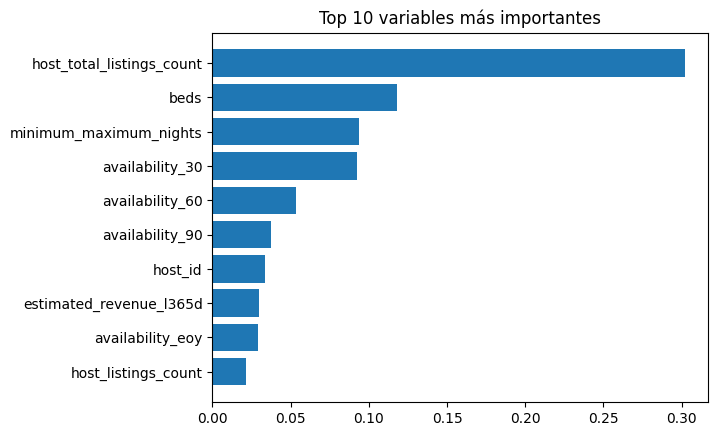

In [19]:
importances = best_rf.feature_importances_
features = X.columns

indices = np.argsort(importances)[-10:]

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), features[indices])
plt.title("Top 10 variables más importantes")
plt.show()

## Conclusión sugerida
Random Forest mejora el desempeño respecto al árbol individual al reducir el sobreajuste mediante el uso de múltiples árboles.